## Calculate kick factors for each IVU gap

The goal of this notebook is to load the elements encoding the IVU geometric and RW impedances for different gaps, and calculate the corresponding theoretical kick factors

### Imports

In [19]:
%matplotlib inline
# %matplotlib notebook
# %matplotlib qt5

from IPython.display import Latex
from IPython.display import SVG

import re
import os
import sh
from functools import reduce
import operator as opr
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot   as mplt
import matplotlib.gridspec as gridspec
import matplotlib.cm       as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

mplt.rcParams.update(
    {'font.size': 10, 'lines.linewidth':2})

import pyaccel
from pymodels import si as si_lat

import pycolleff.impedances as imp
from pycolleff.impedances import element_and_budget as elbud_mod
import pycolleff.rings.sirius as si
import pycolleff.colleff as colleff

utils = importlib.import_module('utils')

### Create Ring Model

In [20]:
mod = si_lat.create_accelerator()

Change RF voltage

In [21]:
famdata = si_lat.get_family_data(mod)

In [22]:
ring = si.create_ring()
ring.gap_voltage = 2.1e6
si.update_from_pymodels(ring, mod)
ring.bunlen = 5e-3

print(ring)

Lattice Version             :   SI.v25.01-s05.02  
Circumference [m]           :       518.387       
Revolution Period [us]      :        1.729        
Revolution Frequency [kHz]  :       578.318       
Energy [GeV]                :        3.000        
U0 [keV]                    :       474.890       
Vgap [MV]                   :        2.100        
Momentum Compaction         :       1.64e-04      
Harmonic Number             :         864         
Current [mA]                :       100.000       
Current per Bunch [mA]      :        0.116        
Synchrotron Tune            :       0.00392       
Tunes x/y                   :    49.096/14.152    
Chromaticities x/y          :     2.500/2.500     
Damping Times x/y/e [ms]    :   16.8/ 21.8 /12.8  
Energy Spread [%]           :        0.0851       
Bunch Length [mm]           :        5.000        



Set fractional parts of the x and y tunes to zero

In [23]:
ring.tunex = 49.00
ring.tuney = 14.00

### Filling Patterns

In [24]:
# Experiment filling pattern
fill_pattern1 = np.zeros(864,)
fill_pattern1[10] = 0.9
fill_pattern1[463] = 0.1

In [41]:
# Naming them for later use
fill_patterns = {
    "Experiment": fill_pattern1,
}

### Load Elements containing Impedance information

In [26]:
folder = 'elements/final/'
files = [
    'ivu_rw_gap_4p3.pickle',
    'ivu_rw_gap_4p6.pickle',
    'ivu_rw_gap_5p0.pickle',
    'ivu_rw_gap_5p6.pickle',
    'ivu_rw_gap_6p6.pickle',
    'ivu_rw_gap_8p2.pickle',
    'ivu_rw_gap_10p3.pickle',
    'ivu_rw_gap_16p0.pickle',
    'ivu_rw_gap_24p0.pickle',
]

els = [imp.load_element(folder + file) for file in files]


In [37]:
for el in els:
    print(el.ang_freq[-1]*1e-9 / (2*np.pi))

8461719.187420083
7892545.251046559
7242953.049314303
6447024.142796254
5449032.789422226
4367338.935442623
3464640.927132632
2219467.327847892
1475303.9320900056


### Truncate frequencies between +-100 GHz

In [29]:
def truncate_element(el, max_ang_freq):
    if el.ang_freq[-1] < max_ang_freq:  # No need to truncate
        return el
    
    mask = np.abs(el.ang_freq) < max_ang_freq

    el.ang_freq = el.ang_freq[mask]  # Truncate freq

    for prop in ["Zll", "Zdx", "Zdy", "Zqx", "Zqy"]:  # Truncate props
        imp = getattr(el, prop)
        if imp is not None and len(imp) > 0:
            setattr(el, prop, imp[mask])

    return el

In [38]:
max_ang_freq = 2*np.pi*100e9  # Corresponding to 100 GHz 

el_procs = [el.copy() for el in els]

for el_proc in el_procs:
    print(el_proc.ang_freq[-1]*1e-9 / (2*np.pi))
    truncate_element(el_proc, max_ang_freq)
    print(el_proc.ang_freq[-1]*1e-9 / (2*np.pi))

8461719.187420083
94.6622811114987
7892545.251046559
99.31712224276511
7242953.049314303
93.44156975898316
6447024.142796254
94.76948024876245
5449032.789422226
92.56959980641005
4367338.935442623
95.70974654973183
3464640.927132632
98.00589920969733
2219467.327847892
94.10814521925339
1475303.9320900056
92.25126070733747


### Calculate Kick Factors

In [39]:
for el in els:
    print(el.name)

IVU RW Gap 4p3
IVU RW Gap 4p6
IVU RW Gap 5p0
IVU RW Gap 5p6
IVU RW Gap 6p6
IVU RW Gap 8p2
IVU RW Gap 10p3
IVU RW Gap 16p0
IVU RW Gap 24p0


In [42]:
imp_types = ['Zdy', 'Zqy', 'Zdx', 'Zqx']

results = []

for el in els:

    for fill_name, fill_pattern in fill_patterns.items():

        for imp_type in imp_types:

            # Plane y
            kd_y, _ = ring.kick_factor(
                element=el, imp_type="Zdy", fillpattern=fill_pattern)
            kq_y, _ = ring.kick_factor(
                element=el, imp_type="Zqy", fillpattern=fill_pattern)

            # Plane x
            kd_x, _ = ring.kick_factor(
                element=el, imp_type="Zdx", fillpattern=fill_pattern)
            kq_x, _ = ring.kick_factor(
                element=el, imp_type="Zqx", fillpattern=fill_pattern)

        results.append({
            "name": el.name,
            "fill_pattern": fill_name,
            "kd_y [V/(pC.m)]": 1e-12 * kd_y,
            "kq_y [V/(pC.m)]": 1e-12 * kq_y,
            "k_y [V/(pC.m)]": 1e-12 * (kd_y + kq_y),
            "kd_x [V/(pC.m)]": 1e-12 * kd_x,
            "kq_x [V/(pC.m)]": 1e-12 * kq_x,
            "k_x [V/(pC.m)]": 1e-12 * (kd_x + kq_x)
        })

results = pd.DataFrame(results)

In [43]:
results

,name,fill_pattern,kd_y [V/(pC.m)],kq_y [V/(pC.m)],k_y [V/(pC.m)],kd_x [V/(pC.m)],kq_x [V/(pC.m)],k_x [V/(pC.m)]
0,IVU RW Gap 4p3,Experiment,-274.670389,-147.389415,-422.059803,-147.389414,147.389414,0.0
1,IVU RW Gap 4p6,Experiment,-224.248574,-120.894024,-345.142598,-120.894024,120.894024,0.0
2,IVU RW Gap 5p0,Experiment,-174.716761,-94.765139,-269.481900,-94.765138,94.765138,0.0
3,IVU RW Gap 5p6,Experiment,-124.706045,-68.241081,-192.947126,-68.241081,68.241081,0.0
4,IVU RW Gap 6p6,Experiment,-76.801059,-42.622999,-119.424058,-42.622999,42.622999,0.0
5,IVU RW Gap 8p2,Experiment,-40.786935,-23.115319,-63.902255,-23.115319,23.115319,0.0
6,IVU RW Gap 10p3,Experiment,-21.181456,-12.306886,-33.488342,-12.306886,12.306886,0.0
7,IVU RW Gap 16p0,Experiment,-6.154237,-3.780728,-9.934964,-3.780728,3.780728,0.0
8,IVU RW Gap 24p0,Experiment,-2.049633,-1.333886,-3.383519,-1.333886,1.333886,0.0


Round to 3 decimal digits

In [75]:
filtered_results = results.copy()

k_cols = [
    "k_y [V/(pC.m)]", "kd_y [V/(pC.m)]", "kq_y [V/(pC.m)]",
    "k_x [V/(pC.m)]", "kd_x [V/(pC.m)]", "kq_x [V/(pC.m)]"
]
filtered_results[k_cols] = filtered_results[k_cols].round(3)

filtered_results = filtered_results[[
    "name", *k_cols
]]

filtered_results

,name,k_y [V/(pC.m)],kd_y [V/(pC.m)],kq_y [V/(pC.m)],k_x [V/(pC.m)],kd_x [V/(pC.m)],kq_x [V/(pC.m)]
0,IVU RW Gap 4p3,-422.060,-274.670,-147.389,0.0,-147.389,147.389
1,IVU RW Gap 4p6,-345.143,-224.249,-120.894,0.0,-120.894,120.894
2,IVU RW Gap 5p0,-269.482,-174.717,-94.765,0.0,-94.765,94.765
3,IVU RW Gap 5p6,-192.947,-124.706,-68.241,0.0,-68.241,68.241
4,IVU RW Gap 6p6,-119.424,-76.801,-42.623,0.0,-42.623,42.623
5,IVU RW Gap 8p2,-63.902,-40.787,-23.115,0.0,-23.115,23.115
6,IVU RW Gap 10p3,-33.488,-21.181,-12.307,0.0,-12.307,12.307
7,IVU RW Gap 16p0,-9.935,-6.154,-3.781,0.0,-3.781,3.781
8,IVU RW Gap 24p0,-3.384,-2.050,-1.334,0.0,-1.334,1.334


See if RW results follow a 1/gap³ trend

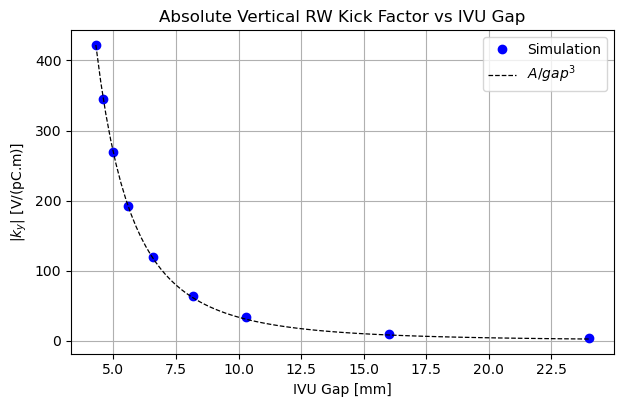

In [77]:
k_y_RW = filtered_results['k_y [V/(pC.m)]']
gaps = np.array([4.3, 4.6, 5.0, 5.6, 6.6, 8.2, 10.3, 16.0, 24.0])  # [mm]

k_y_abs = np.abs(k_y_RW)

# normalize 1/gap^3 curve to pass through first point
A = k_y_abs.iloc[0] * gaps[0]**3

gaps_theory = np.linspace(gaps[0], gaps[-1], 100)
theory = A / gaps_theory**3

fig, ax = mplt.subplots(figsize=(7, 4.2))
ax.plot(gaps, k_y_abs, 'o', color='blue', label='Simulation')
ax.plot(gaps_theory, theory, '--k', linewidth=.9, label=r'$A/gap^3$')

ax.set_xlabel('IVU Gap [mm]')
ax.set_ylabel(r'$|k_y|$ [V/(pC.m)]')
ax.set_title('Absolute Vertical RW Kick Factor vs IVU Gap')
ax.grid(True)
ax.legend();


Add total (Geom + RW) kick factors

In [ ]:
gaps = [4, 14, 24]
for i in range(9):
    name = f'IVU Total Gap {gaps[i]}'
    row1 = filtered_results.iloc[i]
    row2 = filtered_results.iloc[i+9]
    total_i = {
            "name": name,
            "fill_pattern": 'Experiment',
            "k_y [V/(pC.m)]": (row1['k_y [V/(pC.m)]'] + row2['k_y [V/(pC.m)]']).round(3),
            "kd_y [V/(pC.m)]": (row1['kd_y [V/(pC.m)]'] + row2['kd_y [V/(pC.m)]']).round(3),
            "kq_y [V/(pC.m)]": (row1['kq_y [V/(pC.m)]'] + row2['kq_y [V/(pC.m)]']).round(3),
            "k_x [V/(pC.m)]": (row1['k_x [V/(pC.m)]'] + row2['k_x [V/(pC.m)]']).round(3),
            "kd_x [V/(pC.m)]": (row1['kd_x [V/(pC.m)]'] + row2['kd_x [V/(pC.m)]']).round(3),
            "kq_x [V/(pC.m)]": (row1['kq_x [V/(pC.m)]'] + row2['kq_x [V/(pC.m)]']).round(3),
        }
    filtered_results.loc[len(filtered_results)] = total_i


In [26]:
filtered_results

,name,fill_pattern,k_y [V/(pC.m)],kd_y [V/(pC.m)],kq_y [V/(pC.m)],k_x [V/(pC.m)],kd_x [V/(pC.m)],kq_x [V/(pC.m)]
0,IVU Flexible Taper Gap 4,Experiment,-317.719,-298.303,-19.416,-19.027,-37.582,18.555
1,IVU Flexible Taper Gap 14,Experiment,-33.266,-28.479,-4.787,-4.678,-9.251,4.574
2,IVU Flexible Taper Gap 24,Experiment,-33.871,-29.223,-4.648,-4.669,-8.994,4.326
3,IVU RW Gap 4,Experiment,-475.283,-309.619,-165.664,0.000,-165.664,165.664
4,IVU RW Gap 14,Experiment,-13.972,-8.712,-5.260,0.000,-5.260,5.260
5,IVU RW Gap 24,Experiment,-3.346,-2.027,-1.319,0.000,-1.319,1.319
6,IVU Total Gap 4,Experiment,-793.002,-607.922,-185.080,-19.027,-203.246,184.219
7,IVU Total Gap 14,Experiment,-47.238,-37.191,-10.047,-4.678,-14.511,9.834
8,IVU Total Gap 24,Experiment,-37.217,-31.250,-5.967,-4.669,-10.313,5.645


In [27]:
slides_table = filtered_results.loc[range(9), ['name', 'k_y [V/(pC.m)]', 'k_x [V/(pC.m)]']]
slides_table

,name,k_y [V/(pC.m)],k_x [V/(pC.m)]
0,IVU Flexible Taper Gap 4,-317.719,-19.027
1,IVU Flexible Taper Gap 14,-33.266,-4.678
2,IVU Flexible Taper Gap 24,-33.871,-4.669
3,IVU RW Gap 4,-475.283,0.000
4,IVU RW Gap 14,-13.972,0.000
5,IVU RW Gap 24,-3.346,0.000
6,IVU Total Gap 4,-793.002,-19.027
7,IVU Total Gap 14,-47.238,-4.678
8,IVU Total Gap 24,-37.217,-4.669
